In [1]:
import requests
import pandas as pd

SYMBOL = 'BTCUSDT'
INTERVAL = '1m'   # Intervalle d'une minute
LIMIT = 600        # Nombre de lignes à récupérer

def data_collection_api():
    response = requests.get(
        url='https://api.binance.com/api/v3/klines',
        params={
            "symbol": SYMBOL,
            "interval": INTERVAL,
            "limit": LIMIT
        }
    )
    
    if response.status_code != 200:
        print(f"Erreur {response.status_code}")
        return None
    
    data = response.json()
    
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]
    
    # Créer un DataFrame pandas
    df = pd.DataFrame(data, columns=columns)
    
    numeric_cols = ["open", "high", "low", "close", "volume",
                    "quote_asset_volume", "taker_buy_base_volume", "taker_buy_quote_volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    # Convertir timestamps en microsecondes pour Spark
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms").astype('datetime64[us]')
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms").astype('datetime64[us]')
    
    return df

df = data_collection_api()

# Sauvegarder en Parquet avec fastparquet
df.to_parquet("btc_minute_data.parquet", engine="fastparquet", index=False)

print("Fichier Parquet sauvegardé ✅")


Fichier Parquet sauvegardé ✅


In [2]:
import os
os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/amazon-corretto-11.jdk/Contents/Home"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Bitcoin_Data") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()





Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/20 09:54:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.parquet("btc_minute_data.parquet")
df.show(5)

+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+
|          open_time|    open|    high|     low|   close|  volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+
|2026-01-19 22:55:00|92728.02| 92763.6|92728.01|92763.59| 3.45354|2026-01-19 22:55:...|    320288.5285871|            1349|               2.6654|        247179.0247936|     0|
|2026-01-19 22:56:00| 92763.6|92786.13|92763.59|92786.13| 1.33367|2026-01-19 22:56:...|    123732.0510609|             984|              0.71614|         66438.9152482|     0|
|2026-01-19 22:57:00|92786.13|92786.13| 92742.8|92742.81|  1.8181|2026-01-19 22:57:...|    168669.1147379|            23

In [4]:
df.count()

600

In [5]:
df.printSchema()

root
 |-- open_time: timestamp_ntz (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- close_time: timestamp_ntz (nullable = true)
 |-- quote_asset_volume: double (nullable = true)
 |-- number_of_trades: long (nullable = true)
 |-- taker_buy_base_volume: double (nullable = true)
 |-- taker_buy_quote_volume: double (nullable = true)
 |-- ignore: string (nullable = true)



In [6]:
df.describe().show()

26/01/20 09:54:39 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+-----------------+---------------------+----------------------+------+
|summary|             open|             high|              low|            close|           volume|quote_asset_volume| number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+-------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+-----------------+---------------------+----------------------+------+
|  count|              600|              600|              600|              600|              600|               600|              600|                  600|                   600|   600|
|   mean|92034.35968333328|92058.88891666665|92005.13348333328|92031.50044999996|12.93292638333334|1185197.3263426642|         3594.665|   5.7448491666666675|     526453.7864195525|   0.0|
| stddev|672.3198609375667| 666.041499396176|680.336848

column "volume" contient une valeur max plus grande que min ce qui siginfie que nous pouvons avoir des outliers 114 BTC > 0.34 BTC (outliers)
column "quote_asset_volume" une valeur max plus grande que min ce qui siginfie que nous pouvons avoir des outliers (ouliers)
column "number_of_trades" une differenciation entre les valeurs min et max le marché de trads a des ups and downs selon le volume (correlation)
column "taker_buy_quote_volume" une forte demande d achat (outliers)
column "ignore" valeurs est 0 on pourra le supprimé dans la phase de preporcessing 


In [7]:
# Vérifier l'état de la session Spark
print(df.sparkSession)

In [13]:
from pyspark.sql.functions import col

cols_outliers = [
    "volume","quote_asset_volume", "number_of_trades", 
    "taker_buy_base_volume", "taker_buy_quote_volume"
]


def detect_outliers_iqr(df,column):
    #on calcule q1 et q3
    q1= df.approxQuantile(column,[0.25],0.01)[0]
    q3 = df.approxQuantile(column,[0.75],0.01)[0]

    iqr= q3 - q1

    lower = q1 -1.5 * iqr
    upper = q3 + 1.5 * iqr

    #om calcule les outliers
    outlier_count = df.filter(
        (col(column) < lower) | (col(column) > upper)
    ).count()

    return{
        "column": column,
        "Q1" : q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outliers_Count": outlier_count
    }

results = []

for c in cols_outliers:
    res = detect_outliers_iqr(df, c)
    results.append(res)

results



[{'column': 'volume',
  'Q1': 3.21315,
  'Q3': 15.33113,
  'IQR': 12.11798,
  'Lower_Bound': -14.963819999999997,
  'Upper_Bound': 33.5081,
  'Outliers_Count': 38},
 {'column': 'quote_asset_volume',
  'Q1': 297873.5429265,
  'Q3': 1405448.1995622,
  'IQR': 1107574.6566357,
  'Lower_Bound': -1363488.44202705,
  'Upper_Bound': 3066810.18451575,
  'Outliers_Count': 38},
 {'column': 'number_of_trades',
  'Q1': 1586.0,
  'Q3': 4374.0,
  'IQR': 2788.0,
  'Lower_Bound': -2596.0,
  'Upper_Bound': 8556.0,
  'Outliers_Count': 38},
 {'column': 'taker_buy_base_volume',
  'Q1': 1.24141,
  'Q3': 7.32868,
  'IQR': 6.08727,
  'Lower_Bound': -7.889495,
  'Upper_Bound': 16.459585,
  'Outliers_Count': 45},
 {'column': 'taker_buy_quote_volume',
  'Q1': 114830.9235598,
  'Q3': 668759.6622211,
  'IQR': 553928.7386612999,
  'Lower_Bound': -716062.1844321499,
  'Upper_Bound': 1499652.7702130498,
  'Outliers_Count': 46}]

les outliers que nous avons remarqué est normaux puisqu'ils ont moins de 10% donc on va appliquer Capping ou Log transform

In [18]:
from pyspark.sql.functions import col, when

cols_outliers = [
    "volume","quote_asset_volume", "number_of_trades", 
    "taker_buy_base_volume", "taker_buy_quote_volume"
]

upper_bounds = {}
for r in results:
    upper_bounds[r["column"]] = r["Upper_Bound"]

for column in cols_outliers:
    df = df.withColumn(
        f"{column}_capped",
        when(col(column) > upper_bounds[column], upper_bounds[column])
        .otherwise(col(column))
    )

In [22]:

upper_volume = upper_bounds["volume"]

df.filter(col("volume") > upper_volume)\
  .select("volume", "volume_capped")\
  .show(10)

+---------+-------------+
|   volume|volume_capped|
+---------+-------------+
| 36.20241|      33.5081|
|111.90587|      33.5081|
| 42.98858|      33.5081|
| 33.85528|      33.5081|
| 34.72923|      33.5081|
|201.65528|      33.5081|
|149.26967|      33.5081|
|   50.287|      33.5081|
| 64.74601|      33.5081|
| 34.62076|      33.5081|
+---------+-------------+
only showing top 10 rows



In [24]:
#verifier les valeurs nulls

from pyspark.sql.functions import  col, sum as Fsum


df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+-------------+-------------------------+-----------------------+----------------------------+-----------------------------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|volume_capped|quote_asset_volume_capped|number_of_trades_capped|taker_buy_base_volume_capped|taker_buy_quote_volume_capped|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+-------------+-------------------------+-----------------------+----------------------------+-----------------------------+
|        0|   0|   0|  0|    0|     0|         0|                 0|               0|                    0|                     0|     0|            0|                        0|                      0|                

In [29]:
print("duplicates cols :", df.count() - df.dropDuplicates().count())

duplicates cols : 0


### prédire le prix de cloture du Bitcoin à T+10 minutes


In [52]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.sql.functions import col, avg

# Créer une fenêtre ordonnée par temps
window = Window.orderBy("open_time")

# Décaler la colonne 'close' de 10 lignes (10 minutes)
df = df.withColumn("close_t_plus_10", F.lead("close", 10).over(window))

 
#calcule de la Variations de prix (returns) 
window_lag =Window.orderBy("open_time")
df = df.withColumn(
    "return", 
    (F.col("close")-F.lag("close",1).over(window_lag)) / F.lag("close",1).over(window_lag)
    )

#calcule de Moyennes mobiles (5, 10 minutes)
window_avg= Window.orderBy("open_time")
window_5 =window_avg.rowsBetween(-4 , 0)
window_10 = window_avg.rowsBetween(-9,0)

df = df.withColumn("ma_05",avg(col("close")).over(window_5))
df = df.withColumn("ma_10",avg(col("close")).over(window_10)) 


#calculer le taker ratio
df= df.withColumn(
    "taker_ratio",
    F.col("taker_buy_base_volume")/F.col("volume")
)




In [53]:
from pyspark.sql.functions import  col, sum as Fsum


df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

26/01/20 16:15:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:15:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:15:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:15:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:15:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:15:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 1

+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+-------------+-------------------------+-----------------------+----------------------------+-----------------------------+---------------+------+-----+-----+-----------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|volume_capped|quote_asset_volume_capped|number_of_trades_capped|taker_buy_base_volume_capped|taker_buy_quote_volume_capped|close_t_plus_10|return|ma_05|ma_10|taker_ratio|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+-------------+-------------------------+-----------------------+----------------------------+-----------------------------+---------------+------+-----+-----+-----------+
|        0|   0|   0|  0|    0|     0|         0|                 0|        

In [56]:
df_clean = df.dropna(subset=["close_t_plus_10","return"])

In [59]:


# matrice de correlation

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import numpy as np
import pandas as pd

cols_numeric = [
    "close", "volume", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_volume", "taker_buy_quote_volume",
    "return", "ma_05", "ma_10", "taker_ratio", "close_t_plus_10"
]

assembler = VectorAssembler(
    inputCols=cols_numeric,
    outputCol="features"
)
df_vector = assembler.transform(df_clean).select("features")


corr_matrix = Correlation.corr(df_vector, "features").head()[0]


corr_array = corr_matrix.toArray()


corr_df = pd.DataFrame(corr_array, columns=cols_numeric, index=cols_numeric)





26/01/20 16:22:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:22:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:22:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:22:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:22:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 16:22:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/20 1

In [60]:
corr_df.head()

,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return,ma_05,ma_10,taker_ratio,close_t_plus_10
close,1.000000,-0.376480,-0.373513,-0.440325,-0.418381,-0.414713,0.058007,0.996638,0.992335,-0.055082,0.972896
volume,-0.376480,1.000000,0.999980,0.790013,0.695368,0.695140,-0.241885,-0.347036,-0.326125,-0.082768,-0.359646
quote_asset_volume,-0.373513,0.999980,1.000000,0.790273,0.695406,0.695212,-0.242320,-0.344034,-0.323121,-0.083039,-0.356941
number_of_trades,-0.440325,0.790013,0.790273,1.000000,0.638427,0.638410,-0.191932,-0.412767,-0.390463,-0.073776,-0.416478
taker_buy_base_volume,-0.418381,0.695368,0.695406,0.638427,1.000000,0.999976,0.202174,-0.423313,-0.408906,0.309151,-0.413910


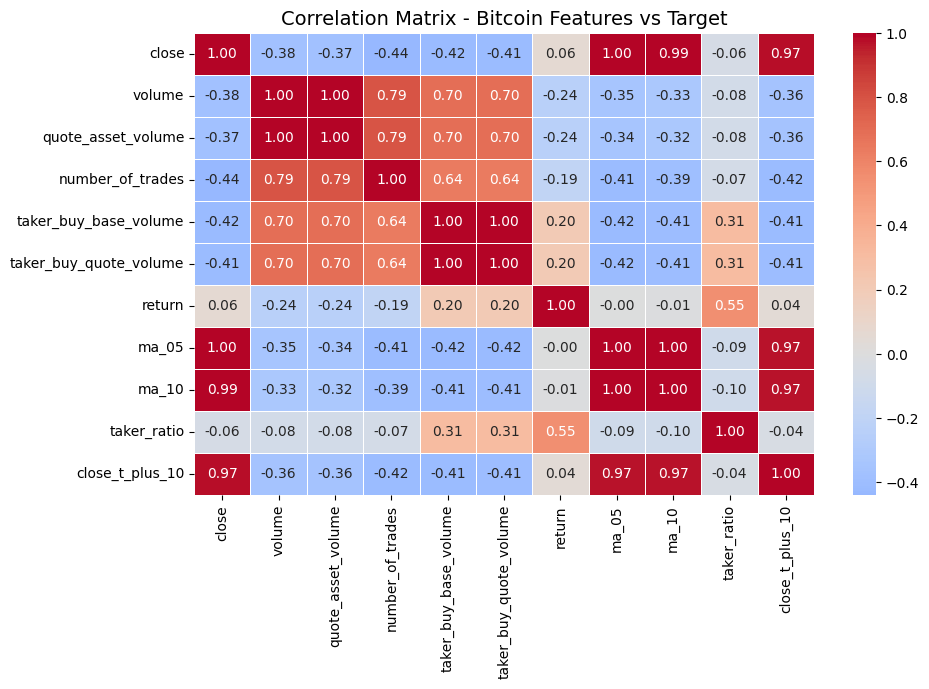

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_df,
    annot=True,       
    fmt=".2f",        
    cmap="coolwarm",   
    center=0,         
    linewidths=0.5
)

plt.title("Correlation Matrix - Bitcoin Features vs Target", fontsize=14)
plt.show()